In [9]:
# Domain – Retail/Fashion focus – Optimize sales
# Business challenge/requirement

# Fyntra is the largest online clothing company in USA. It sells clothing online, but they also have in-store style and clothing advice sessions. Customers come into the store, have sessions/meetings with a personal stylist, then can go home and order either on a mobile app or website for the clothes they want.
# Company wants to decide whether to focus the effort on mobile app experience or its website. As a drastic measure it is also evaluating to shut down the website.
# You as a ML expert in the team will help the company make the right decision
# Key issues
# Clearly establish a correlation among the parameters supplied in data
# Considerations NONE
# Data volume
# Approx 500 records – file FyntraCustomerData.csv (All data is fake so do not worry about privacy)
# Additional information
# -	NA
# Business benefits
# Increase in profits as the focus on the optimal sales channel will result into the higher top line and the higher bottom line


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("/content/FyntraCustomerData.csv")
data.head()

,Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


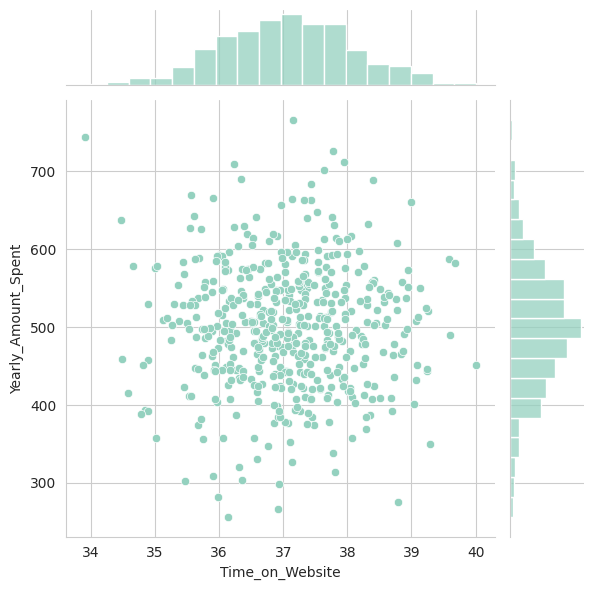

In [11]:
# 1.	Compute -- Use seaborn to create a jointplot to compare the Time on Website and Yearly Amount Spent columns. Is there a correlation?
sns.jointplot(data=data,x='Time_on_Website',y='Yearly_Amount_Spent')

Object `One` not found.


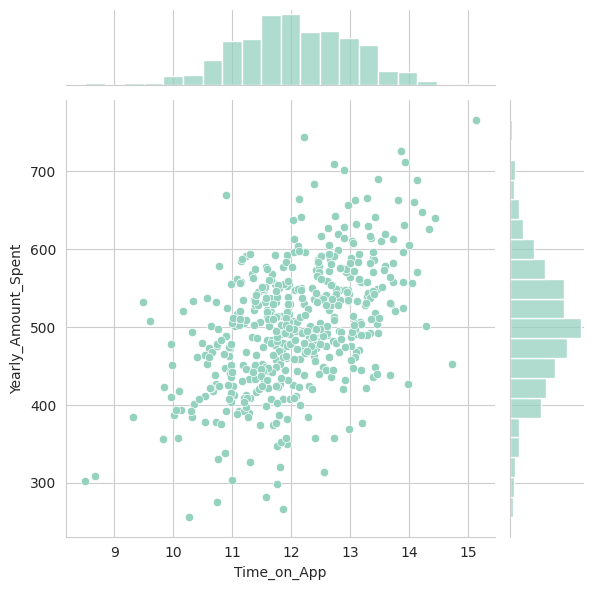

In [13]:
# 2.	Compute – Do the same as above but now with Time on App and Yearly Amount Spent. Is this correlation stronger than 1st One?
sns.jointplot(data=data,x='Time_on_App',y='Yearly_Amount_Spent')

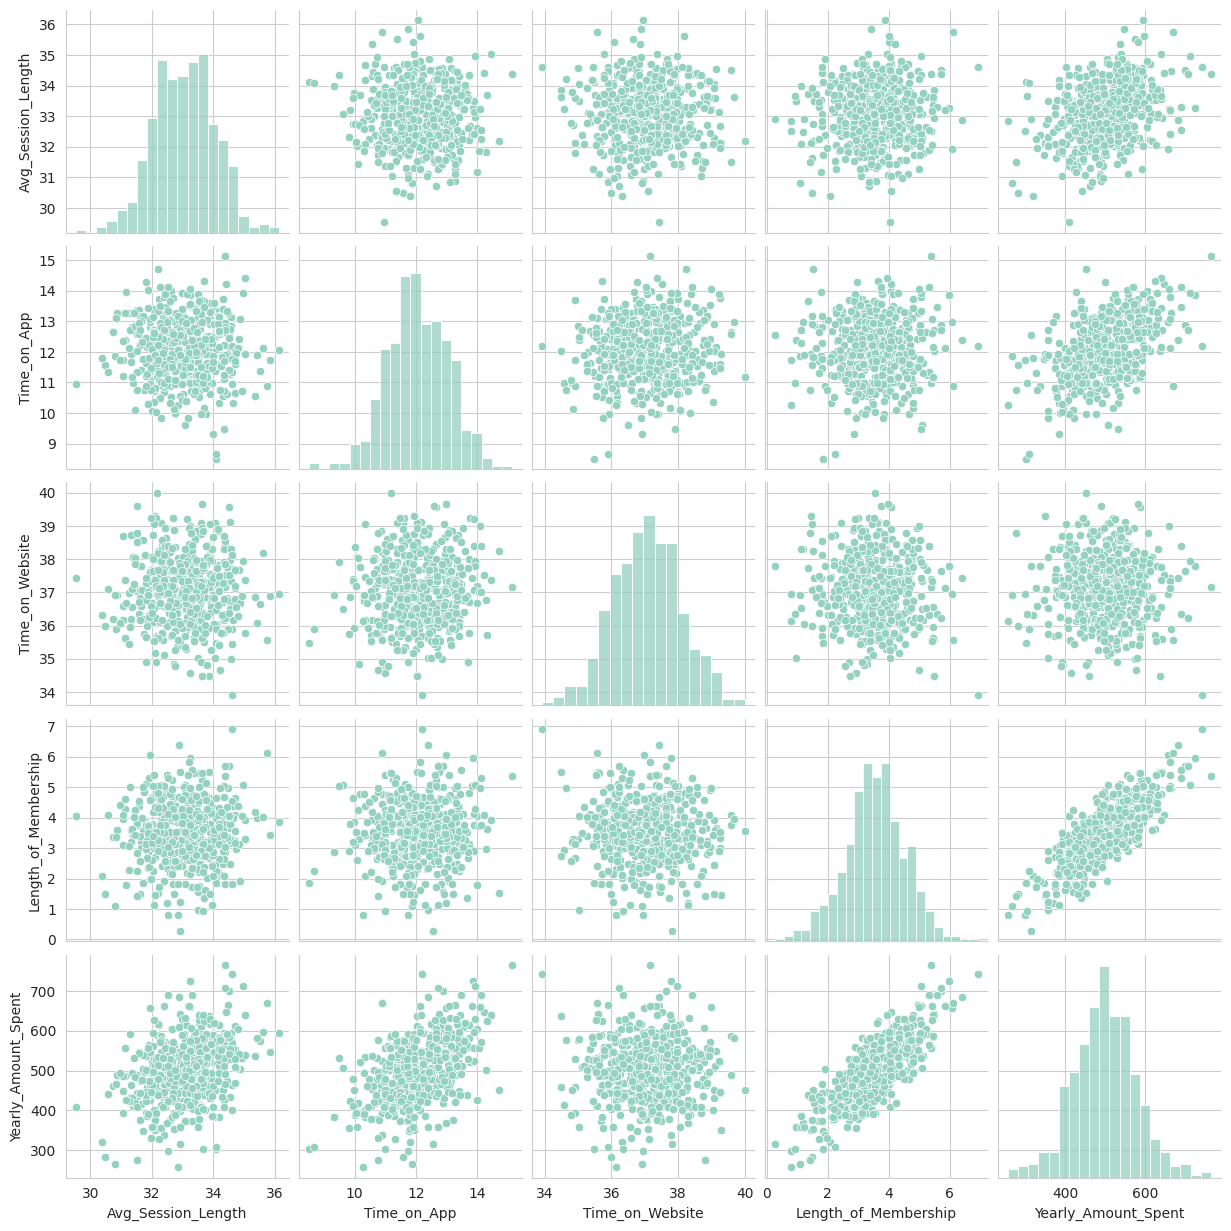

In [19]:
# 3.	Compute -- Explore types of relationships across the entire data set using pairplot . Based off this plot what looks to be the most correlated feature with Yearly Amount Spent?
sns.pairplot(data)

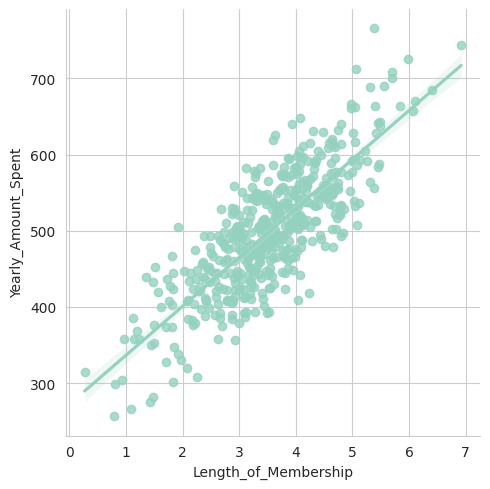

In [24]:
# 4.	Compute – Create linear model plot of Length of Membership and Yearly Amount Spent. Does the data fits well in linear plot? – Seaborn LM Plot
sns.lmplot(data=data,x='Length_of_Membership', y='Yearly_Amount_Spent')


In [30]:
# 5.	Compute – Train and Test the data and answer multiple questions -- What is the use of random_state=85?
x=data.iloc[:,3:-1]
y=data.iloc[:,-1]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=85)
print(x_train.shape,y_train.shape)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

(350, 4) (350,)


LinearRegression()

Text(0, 0.5, 'Predicted Y')

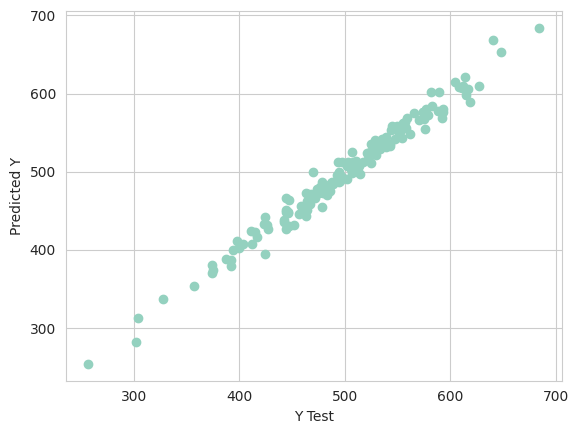

In [32]:
# 6.	Compute – Predict the data and do a scatter plot. Check if actual and predicted data match?
y_pred=lr.predict(x_test)
plt.scatter(y_test,y_pred)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

In [36]:
# 7.	What is the value of Root Mean Squared Error?
from sklearn.metrics import root_mean_squared_error

print(root_mean_squared_error(y_test,y_pred))
print('Coefficients: \n', lr.coef_)
print('Intercept: \n', lr.intercept_)


10.572658672879333
Coefficients: 
 [26.08163249 39.18778762  0.40460005 61.41777824]
Intercept: 
 -1067.3824276105236


/tmp/ipykernel_7043/2185108063.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-y_pred),bins=50)


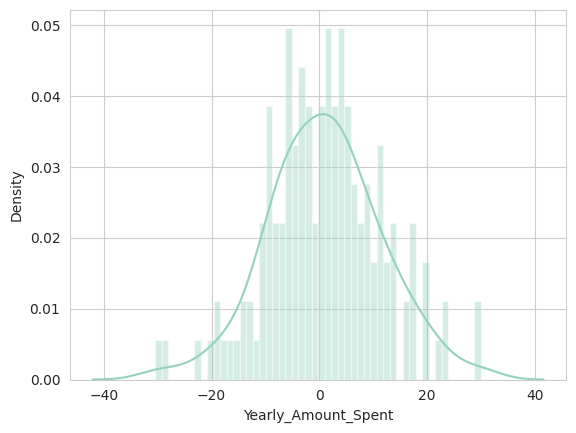

In [34]:
sns.distplot((y_test-y_pred),bins=50)
plt.show()

In [38]:
# ** Q8. Based on coefficients interpret company should focus more on their mobile app or on their website**

coeffecients = pd.DataFrame(lr.coef_,x.columns)
coeffecients.columns = ['Coeffecient']
coeffecients


,Coeffecient
Avg_Session_Length,26.081632
Time_on_App,39.187788
Time_on_Website,0.404600
Length_of_Membership,61.417778


Focus on App more than website
